# Download images from Coco dataset

## Download annotations first :
Step by Step:
- https://cocodataset.org/
- click on menu Dataset
- download
- annotations
- 2017 Train/Val annotations [241MB]

This should start download of file http://images.cocodataset.org/annotations/annotations_trainval2017.zip

Original file: https://github.com/cocodataset/cocoapi/blob/master/PythonAPI/pycocoDemo.ipynb

## Methods

* Throughout the API "ann"=annotation, "cat"=category, and "img"=image.
* getAnnIds - Get ann ids that satisfy given filter conditions.
* getCatIds - Get cat ids that satisfy given filter conditions.
* getImgIds - Get img ids that satisfy given filter conditions.
* loadAnns - Load anns with the specified ids.
* loadCats - Load cats with the specified ids.
* loadImgs - Load imgs with the specified ids.
* loadRes - Load algorithm results and create API for accessing them.
* showAnns - Display the specified annotations.

## Import

In [29]:
# install pycocotools

%matplotlib inline
from pycocotools.coco import COCO
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
import pylab
pylab.rcParams['figure.figsize'] = (8.0, 10.0)

## Select one Coco dataset

In [30]:
#dataDir= '..'
dataType='val2017'
#dataType='train2017'
#annFile='{}/annotations/instances_{}.json'.format(dataDir,dataType)
annFile='annotations/instances_{}.json'.format(dataType)
print(annFile)

annotations/instances_val2017.json


In [31]:
# initialize COCO api for instance annotations
coco=COCO(annFile)

loading annotations into memory...
Done (t=0.54s)
creating index...
index created!


In [32]:
# display COCO categories and supercategories
cats = coco.loadCats(coco.getCatIds())
nms=[cat['name'] for cat in cats]
print('COCO categories: \n{}\n'.format(' '.join(nms)))

nms = set([cat['supercategory'] for cat in cats])
print('COCO supercategories: \n{}'.format(' '.join(nms)))

COCO categories: 
person bicycle car motorcycle airplane bus train truck boat traffic light fire hydrant stop sign parking meter bench bird cat dog horse sheep cow elephant bear zebra giraffe backpack umbrella handbag tie suitcase frisbee skis snowboard sports ball kite baseball bat baseball glove skateboard surfboard tennis racket bottle wine glass cup fork knife spoon bowl banana apple sandwich orange broccoli carrot hot dog pizza donut cake chair couch potted plant bed dining table toilet tv laptop mouse remote keyboard cell phone microwave oven toaster sink refrigerator book clock vase scissors teddy bear hair drier toothbrush

COCO supercategories: 
sports person furniture accessory outdoor kitchen electronic animal appliance indoor food vehicle


### Get images Id for images labeled as selected categories

In [ ]:
# get all images containing given categories, select one at random
category_Ids = coco.getCatIds(catNms=['person','dog','cat'])
imgIds = coco.getImgIds(catIds = category_Ids )
imgIds = coco.getImgIds(imgIds = imgIds[0]) #get 1st image
#imgIds = coco.getImgIds(imgIds = imgIds[10]) #get 11th image
img = coco.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]
print('Image URL:', img['coco_url']) # url for the coco image

Image URL: http://images.cocodataset.org/val2017/000000169076.jpg


### Original image

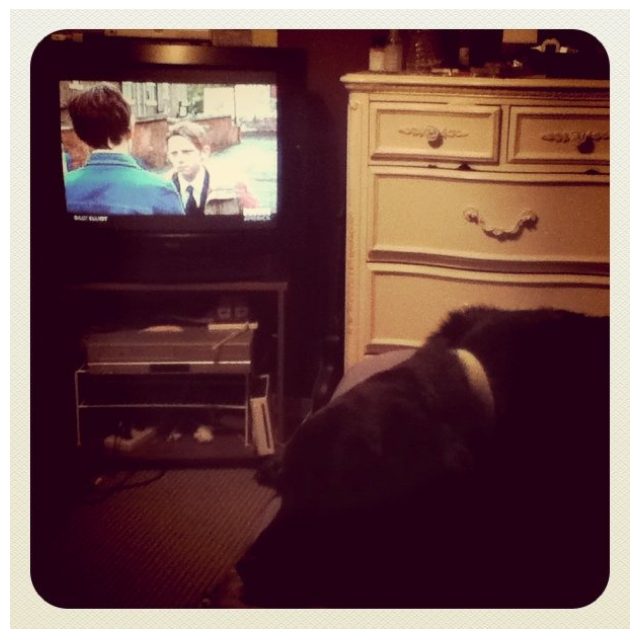

In [34]:
# load and display image
# I = io.imread('%s/images/%s/%s'%(dataDir,dataType,img['file_name']))
# use url to load image
I = io.imread(img['coco_url'])
plt.axis('off')
plt.imshow(I)
plt.show()

### Segmented image

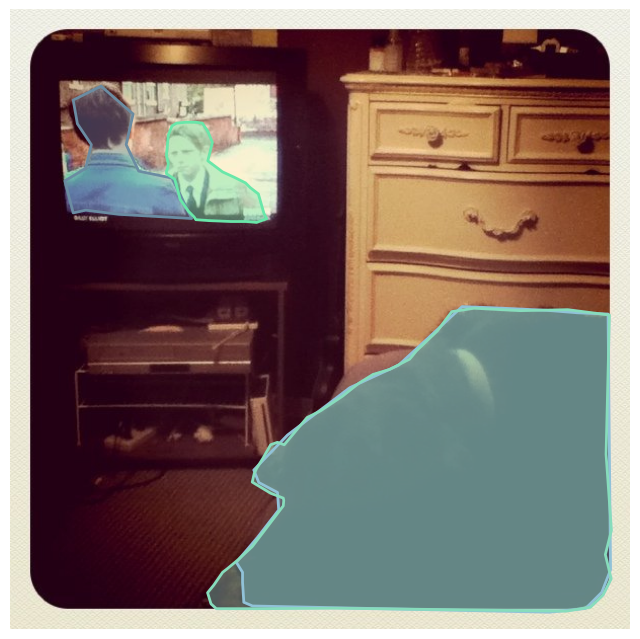

In [35]:
# load and display instance annotations
plt.imshow(I); plt.axis('off')
annIds = coco.getAnnIds(imgIds=img['id'], catIds=category_Ids, iscrowd=None)
anns = coco.loadAnns(annIds)
coco.showAnns(anns)

In [36]:
# initialize COCO api for person keypoints annotations
# annFile = '{}/annotations/person_keypoints_{}.json'.format(dataDir,dataType)
annFile='annotations/person_keypoints_{}.json'.format(dataType)
# annFile='annotations/instances_{}.json'.format(dataType)
coco_kps=COCO(annFile)

loading annotations into memory...
Done (t=0.24s)
creating index...
index created!


### Segmented image with keypoints

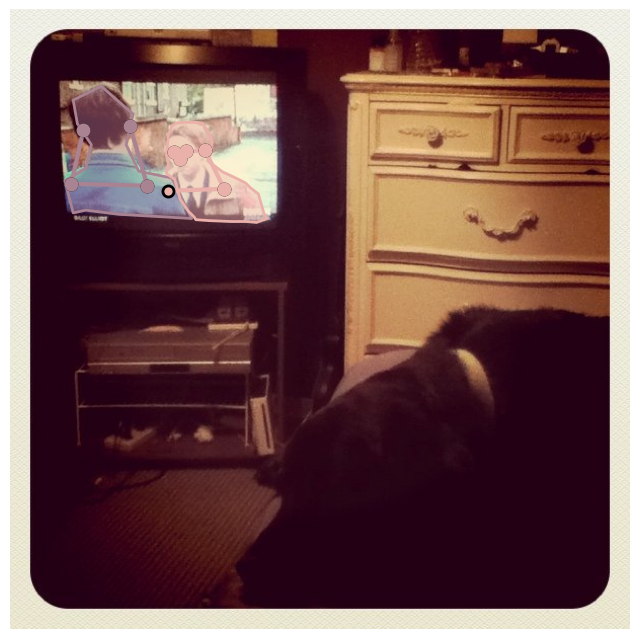

In [37]:
# load and display keypoints annotations
plt.imshow(I); plt.axis('off')
ax = plt.gca()
annIds = coco_kps.getAnnIds(imgIds=img['id'], catIds=category_Ids, iscrowd=None)
anns = coco_kps.loadAnns(annIds)
coco_kps.showAnns(anns)

In [38]:
# initialize COCO api for caption annotations
#annFile = '{}/annotations/captions_{}.json'.format(dataDir,dataType)
annFile = 'annotations/captions_{}.json'.format(dataType)
coco_caps=COCO(annFile)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


### Show image caption annotatins

A television is on a tv stand next to a bureau. 
A photo of someone watching TV with their dog.
A dog laying on a bed with a television in the background.
A dog laying in a room near a television and dresser.
A black dog laying down not watching the TV that is turned on.


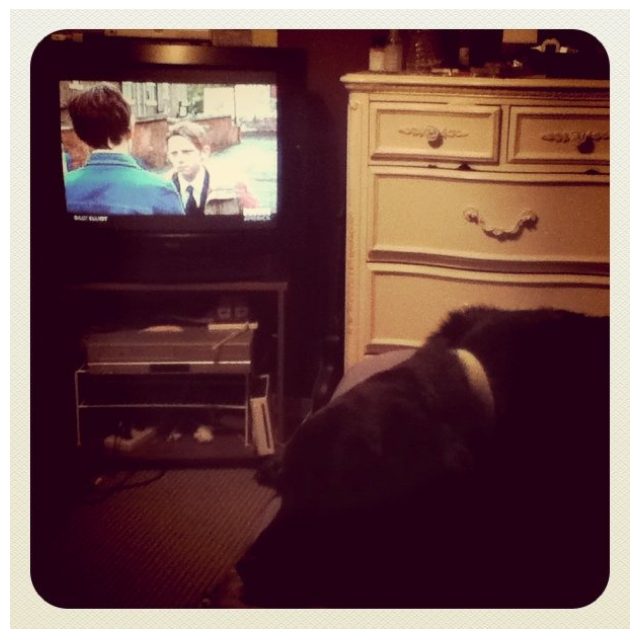

In [39]:
# load and display caption annotations
annIds = coco_caps.getAnnIds(imgIds=img['id'])
anns = coco_caps.loadAnns(annIds)
coco_caps.showAnns(anns)
plt.imshow(I); plt.axis('off'); plt.show()